In [1]:
import numpy as np
import matplotlib.pyplot as pl
from five_vec import five_vec

## Shows the 5 vector code works for a monochromatic signal

In [10]:
c = 3e8
G = 6.67e-11
pi = np.pi
f0 = 21
# We define a shorter sidereal day to verify the code without requiring large memory usage
side_day = 900.02 #86164.09053083288
number_of_days = 3 # needs to be integer
T_obs = number_of_days*side_day #need to ensure this is integer of t_side

f_signal = 10*f0
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal

#Monochromatic signal
mono = np.exp(1j*2*pi*f0*t)

In [11]:
# This uses five_vec.py to compute the doppler modulation of the signal
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

In [12]:
signal = mono*amp_modulation
fft_freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), np.diff(t)[0]))
fft_amps = np.fft.fftshift(np.fft.fft(signal))/len(signal)

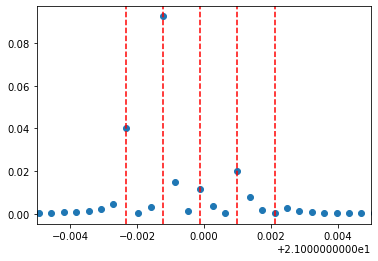

In [13]:
# We verify that the modulated waveform has the distinctive five peaks expected
expected_f = fft_freqs[abs(fft_freqs-f0).argmin()]
pl.plot(fft_freqs, abs(fft_amps)**2, 'o')
pl.xlim(f0-0.005, f0+0.005)
pl.axvline(expected_f-2/side_day, c='r', ls='--')
pl.axvline(expected_f-1/side_day, c='r', ls='--')
pl.axvline(expected_f, c='r', ls='--')
pl.axvline(expected_f+1/side_day, c='r', ls='--')
pl.axvline(expected_f+2/side_day, c='r', ls='--')

In [14]:
X = np.empty((5), dtype=complex)

f0_idx = abs(fft_freqs-f0).argmin()
X[0] = fft_amps[f0_idx-2*number_of_days]
X[1] = fft_amps[f0_idx-number_of_days]
X[2] = fft_amps[f0_idx]
X[3] = fft_amps[f0_idx+number_of_days]
X[4] = fft_amps[f0_idx+2*number_of_days]

In [15]:
# Here we compute the five vector statistic and check how much power it recovers
estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))
print(estimator)
print(2.4306/pi<estimator)

0.8462950287571832
True
